### Importação de Bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as signal
import IPython.display as ipd
from google.colab import drive
drive.flush_and_unmount()  # desmonta
drive.mount('/content/drive')  # monta de novo
Fs, y = wav.read('/content/drive/MyDrive/Engenharia De Telecomunicações - 88 - Eduardo de Andrade Paziani Kouguem (2023)/2025/6° Semestre/PDS/creed_overcome.wav')
#Fs, y = wav.read('creed_overcome.wav')


def filtro(omega_p, omega_r, numtaps=201):
    """
    Gera um filtro FIR passa-baixas usando janela de Hamming.

    Parâmetros:
    -----------
    omega_p : float
        Frequência de passagem (normalizada por Nyquist, entre 0 e 0.5).
    omega_r : float
        Frequência de rejeição (normalizada por Nyquist, entre 0 e 0.5).
    numtaps : int
        Número de coeficientes (quanto maior, melhor a rejeição, mas maior o custo)

    Retorna:
    --------
    h : array
        Coeficientes do filtro FIR
    """
    cutoff = (omega_p + omega_r) / 2
    h = signal.firwin(numtaps, cutoff, window="hamming")
    return h

import matplotlib.pyplot as plt

def espectro(x, Fs, titulo="Espectro"):
    """
    Plota o espectro de magnitude de um sinal x[n].

    Parâmetros:
    -----------
    x : array
        Sinal de entrada
    Fs : int
        Frequência de amostragem (Hz)
    titulo : str
        Título do gráfico
    """
    N = 8192  # tamanho da FFT
    X = np.fft.fftshift(np.fft.fft(x, N))
    freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/Fs))

    plt.figure(figsize=(10,4))
    plt.plot(freqs, 20*np.log10(np.abs(X)+1e-6))
    plt.title(titulo)
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Mounted at /content/drive


# 2.1 Questões

## (a) ) Mostre o espectro de frequências do sinal de áudio e discuta seu conteúdo
espectral.


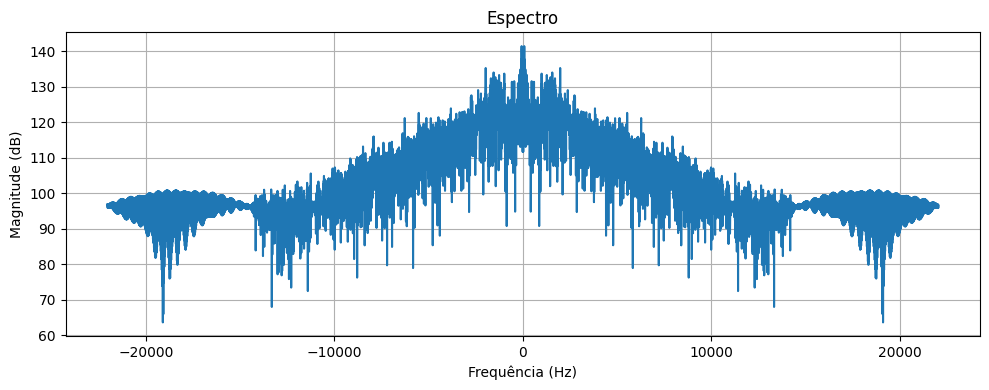

In [ ]:
y = y[:, 0] + y[:, 1]
espectro(y, Fs)

## b) subamostragem M = 6

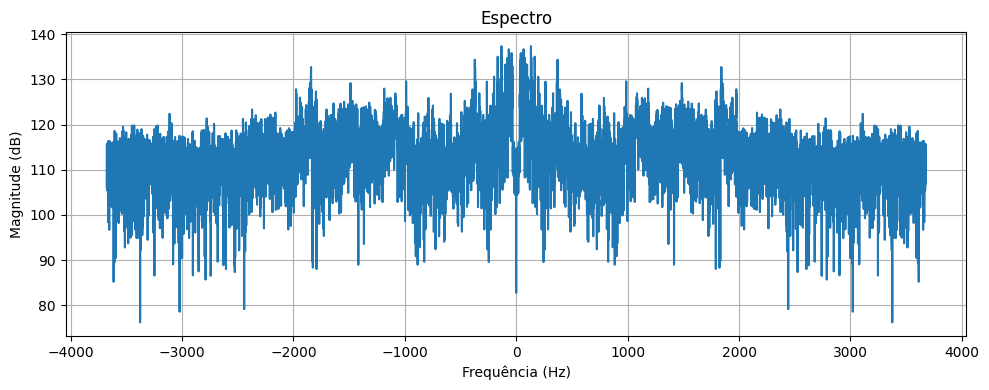

In [ ]:
M = 6
y_sub = y[::M]   # Subamostragem
# Mostrar espectro
espectro(y_sub, Fs/M)

## c) comparação áudio original vs subamostrado

In [ ]:
from IPython.display import display, Markdown

display(Markdown("### 🔊 Sinal Original"))
display(ipd.Audio(y, rate=Fs))
display(Markdown("### 🔊 Sinal Subamostrado"))
display(ipd.Audio(y_sub, rate=Fs/M))


### 🔊 Sinal Original

### 🔊 Sinal Subamostrado

### d)Filtrar com passa-baixas para evitar aliasing

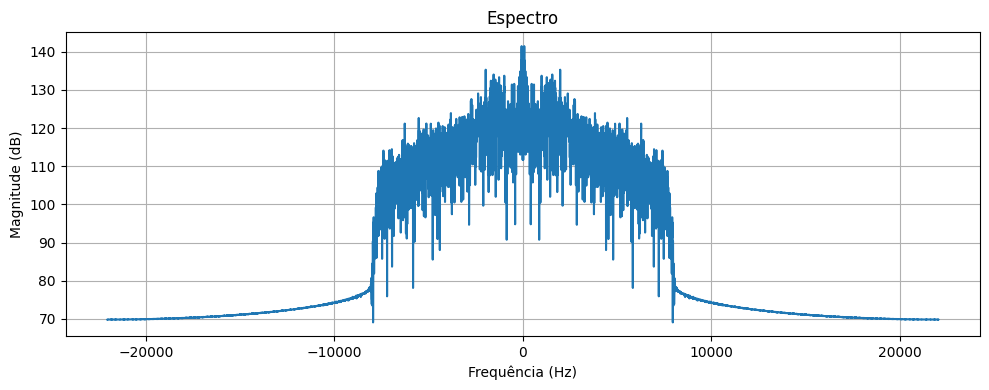

In [ ]:
# Escolha de frequências de passagem e rejeição (normalizadas)
wp = 0.3
wr = 0.4
h = filtro(wp, wr)

# Aplicar o filtro FIR no sinal
y_filt = signal.convolve(y, h, mode='same')

# Mostrar espectro filtrado
espectro(y_filt, Fs)

# Escutar som filtrado
ipd.Audio(y_filt, rate=Fs)

### e) — Subamostragem do sinal filtrado

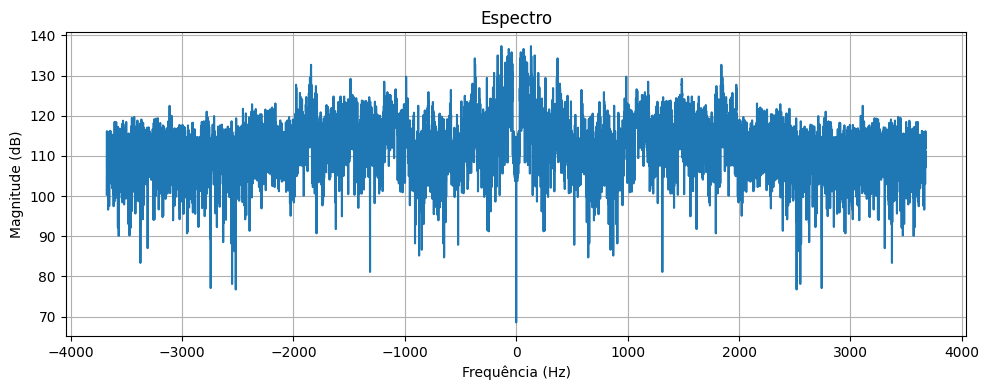

In [ ]:
y_filt_sub = y_filt[::M]
espectro(y_filt_sub, Fs/M)

# Escutar sinal filtrado e subamostrado
ipd.Audio(y_filt_sub, rate=Fs//M)
